# Task 2: Late Fusion mit Wav2Vec2 Features

Dieses Notebook verwendet die **exakte Konfiguration des besten Modells** (experiment_20251116_132709, F1=0.594) für wissenschaftlich vergleichbare Ergebnisse mit klassischen ML-Modellen (SVM, XGBoost, Logistic Regression).

## 1. Setup und Imports

Installation und Import aller benötigten Bibliotheken für Late Fusion mit Wav2Vec2.

In [1]:
# Installations (falls benötigt)
# !pip install transformers soundfile torch scikit-learn xgboost pandas numpy matplotlib seaborn tqdm

In [2]:
import numpy as np
import pandas as pd
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
from tqdm import tqdm
from scipy.signal import resample
from typing import List, Optional, Tuple

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, 
                            precision_score, recall_score, accuracy_score)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ Alle Bibliotheken erfolgreich importiert")

✓ Alle Bibliotheken erfolgreich importiert


## 2. Konfiguration (Bestes Modell)

Diese Konfiguration entspricht **experiment_20251116_132709** (F1=0.594, bestes Modell):

In [3]:
# ============================================================================
# BESTE KONFIGURATION (experiment_20251116_132709: F1=0.594)
# ============================================================================
print("="*80)
print("🏆 OPTIMALE WAV2VEC2 KONFIGURATION (F1=0.594)")
print("="*80)
print("Basierend auf experiment_20251116_132709 (bestes Modell)\n")
print("Feature Extractor Config:")
print("  - Model: facebook/wav2vec2-large-960h")
print("  - Pooling: mean (über Zeit-Dimension)")
print("  - Layers: [6, 9, 12, 15, 18] (5 Transformer-Layer)")
print("  - Layer Fusion: concat")
print("  - Feature Dimension: 5120 (1024 × 5 layers)")
print("\nTraining Details:")
print("  - Training Samples: 219")
print("  - Validation Samples: 53")
print("  - Files per Sample: 8 (5 Phonationen + 3 Rhythmen)")
print("  - Total Feature Dim: 40960 (5120 × 8 files)")
print("="*80 + "\n")

# Wav2Vec2 Konfiguration
MODEL_NAME = "facebook/wav2vec2-large-960h"
LAYERS = [6, 9, 12, 15, 18]  # Multi-layer feature extraction
POOLING = "mean"  # Mean pooling über Zeit-Dimension
LAYER_FUSION = "concat"  # Concatenation der Layer-Features

# Pfade
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1')
EXCEL_PATH = DATA_PATH / 'sand_task_1.xlsx'
TASK_DIR = DATA_PATH / 'training'

print(f"✓ Konfiguration geladen")
print(f"  Data Path: {DATA_PATH}")
print(f"  Excel Path: {EXCEL_PATH}")
print(f"  Task Directory: {TASK_DIR}\n")

🏆 OPTIMALE WAV2VEC2 KONFIGURATION (F1=0.594)
Basierend auf experiment_20251116_132709 (bestes Modell)

Feature Extractor Config:
  - Model: facebook/wav2vec2-large-960h
  - Pooling: mean (über Zeit-Dimension)
  - Layers: [6, 9, 12, 15, 18] (5 Transformer-Layer)
  - Layer Fusion: concat
  - Feature Dimension: 5120 (1024 × 5 layers)

Training Details:
  - Training Samples: 219
  - Validation Samples: 53
  - Files per Sample: 8 (5 Phonationen + 3 Rhythmen)
  - Total Feature Dim: 40960 (5120 × 8 files)

✓ Konfiguration geladen
  Data Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1
  Excel Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/sand_task_1.xlsx
  Task Directory: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training



In [4]:
# Lade Wav2Vec2 Modell und Processor
print("Lade Wav2Vec2 Modell...")
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
wav2vec_model = Wav2Vec2Model.from_pretrained(MODEL_NAME)

# Device (CUDA, MPS oder CPU)
device = torch.device("cuda" if torch.cuda.is_available() else 
                      "mps" if torch.backends.mps.is_available() else "cpu")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print(f"✓ Modell geladen auf Device: {device}")
print(f"✓ Base hidden size: {wav2vec_model.config.hidden_size}")
print(f"✓ Anzahl Layer: {len(wav2vec_model.encoder.layers)}")
print(f"✓ Extrahiere von Layers: {LAYERS}")
print(f"✓ Feature Dimension pro Layer: {wav2vec_model.config.hidden_size}")
print(f"✓ Feature Dimension total: {wav2vec_model.config.hidden_size * len(LAYERS)}\n")

Lade Wav2Vec2 Modell...


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modell geladen auf Device: mps
✓ Base hidden size: 1024
✓ Anzahl Layer: 24
✓ Extrahiere von Layers: [6, 9, 12, 15, 18]
✓ Feature Dimension pro Layer: 1024
✓ Feature Dimension total: 5120



## 4. Feature Extraction Funktionen

Implementierung der Multi-Layer Feature Extraction (wie im besten Modell).

In [5]:
def extract_features_from_file(audio_path: str, 
                               processor: Wav2Vec2Processor, 
                               model: Wav2Vec2Model, 
                               device: torch.device,
                               layers: List[int] = [6, 9, 12, 15, 18],
                               pooling: str = "mean") -> Optional[np.ndarray]:
    """
    Extrahiere Multi-Layer Wav2Vec2 Features von einer Audio-Datei.
    
    Diese Funktion entspricht EXAKT der Konfiguration des besten Modells
    (experiment_20251116_132709, F1=0.594).
    
    Args:
        audio_path: Pfad zur Audio-Datei
        processor: Wav2Vec2 processor
        model: Wav2Vec2 model
        device: Compute device
        layers: Liste der Transformer-Layer-Indizes
        pooling: Pooling-Strategie ("mean", "max", "first", "last")
    
    Returns:
        Feature-Vektor der Form (hidden_size * num_layers,)
    """
    try:
        # Lade Audio-Datei
        audio, sr = sf.read(audio_path)
        
        # Konvertiere zu Mono falls Stereo
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Upsample zu 16kHz falls nötig
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Normalisiere Audio zu [-1, 1]
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        
        # Verarbeite Audio mit Wav2Vec2 Processor
        inputs = processor(
            audio,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )
        
        # Verschiebe zu Device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Extrahiere Features von mehreren Layers
        with torch.no_grad():
            outputs = model(
                **inputs,
                output_hidden_states=True  # Hole alle Layer-Outputs
            )
            
            # Extrahiere von spezifizierten Layers
            hidden_states = outputs.hidden_states  # Tuple aller Layer-Outputs
            layer_features = []
            
            for layer_idx in layers:
                layer_output = hidden_states[layer_idx]  # (batch, time, hidden_size)
                
                # Wende Pooling-Strategie an
                if pooling == "mean":
                    pooled = layer_output.mean(dim=1)  # Durchschnitt über Zeit
                elif pooling == "max":
                    pooled = layer_output.max(dim=1)[0]  # Max über Zeit
                elif pooling == "first":
                    pooled = layer_output[:, 0, :]  # Erster Frame
                elif pooling == "last":
                    pooled = layer_output[:, -1, :]  # Letzter Frame
                else:
                    pooled = layer_output.mean(dim=1)  # Default: mean
                
                layer_features.append(pooled)
            
            # Concateniere Features von allen Layers
            fused_features = torch.cat(layer_features, dim=1)  # (batch, hidden_size * num_layers)
            
        return fused_features.squeeze(0).cpu().numpy()
        
    except Exception as e:
        print(f"❌ Fehler beim Verarbeiten von {audio_path}: {e}")
        return None


print("✓ Feature Extraction Funktion geladen")
print(f"  - extract_features_from_file(): Extrahiere von einzelner Datei")
print(f"  - Konfiguration: {len(LAYERS)} layers, {POOLING} pooling")
print(f"  - Output Dimension: {wav2vec_model.config.hidden_size * len(LAYERS)}\n")

✓ Feature Extraction Funktion geladen
  - extract_features_from_file(): Extrahiere von einzelner Datei
  - Konfiguration: 5 layers, mean pooling
  - Output Dimension: 5120



## 5. Daten laden (Training & Validation Split wie im besten Modell)

Wir laden die Daten **exakt wie im Python-Skript**, um wissenschaftlich vergleichbare Ergebnisse zu erhalten.

**Wichtig:**
- Training Set: 'Training Baseline - Task 1' Sheet
- Validation Set: 'Validation Baseline - Task 1' Sheet
- Jedes Sample besteht aus **8 Audio-Dateien** (5 Phonationen + 3 Rhythmen)
- Nur Samples mit **allen 8 Dateien** werden verwendet

In [6]:
def load_train_val_data_like_best_model(excel_path: Path, 
                                        task_dir: Path) -> Tuple[List, List, List, List]:
    """
    Lädt Daten EXAKT wie im besten Modell (experiment_20251116_132709).
    
    Returns:
        (X_train_files, y_train, X_val_files, y_val)
        wobei X_*_files Listen von 8-File-Groups sind
    """
    
    # Audio-Ordner-Mapping
    audio_folders = {
        "phonationA": "phonationA",
        "phonationE": "phonationE",
        "phonationI": "phonationI",
        "phonationO": "phonationO",
        "phonationU": "phonationU",
        "rhythmKA": "rhythmKA",
        "rhythmPA": "rhythmPA",
        "rhythmTA": "rhythmTA",
    }
    
    def load_dataset(sheet_name: str):
        """Lädt ein Dataset aus einem Excel-Sheet"""
        df_labels = pd.read_excel(excel_path, sheet_name=sheet_name)
        
        file_groups = []
        labels = []
        skipped = 0
        
        for _, row in df_labels.iterrows():
            individual_id = row['ID']
            label = row['Class'] - 1  # Convert zu 0-based!
            
            # Sammle alle 8 Audio-Dateien
            file_paths = []
            for folder_name, file_pattern in audio_folders.items():
                folder_path = task_dir / folder_name
                audio_file = folder_path / f"{individual_id}_{file_pattern}.wav"
                
                if audio_file.exists():
                    file_paths.append(str(audio_file))
                else:
                    break  # Falls eine Datei fehlt, überspringe Sample
            
            # Nur hinzufügen, wenn alle 8 Dateien vorhanden
            if len(file_paths) == 8:
                file_groups.append(file_paths)
                labels.append(label)
            else:
                skipped += 1
        
        if skipped > 0:
            print(f"  ⚠️  Übersprungen: {skipped} Samples mit fehlenden Dateien")
        
        return file_groups, labels
    
    print("="*70)
    print("LADE DATEN (Wie bestes Modell - experiment_20251116_132709)")
    print("="*70)
    
    # Lade Training Set
    print("\n📂 Lade Training Set...")
    X_train_files, y_train = load_dataset('Training Baseline - Task 1')
    print(f"✓ Training Samples: {len(X_train_files)} (je mit 8 Audio-Dateien)")
    
    # Lade Validation Set
    print("\n📂 Lade Validation Set...")
    X_val_files, y_val = load_dataset('Validation Baseline - Task 1')
    print(f"✓ Validation Samples: {len(X_val_files)} (je mit 8 Audio-Dateien)")
    
    # Klassen-Verteilung
    print("\n📊 Klassen-Verteilung:")
    train_classes = pd.Series(y_train).value_counts().sort_index()
    val_classes = pd.Series(y_val).value_counts().sort_index()
    
    print("\nTraining Set:")
    for cls, count in train_classes.items():
        print(f"  Klasse {cls}: {count} Samples ({count/len(y_train)*100:.1f}%)")
    
    print("\nValidation Set:")
    for cls, count in val_classes.items():
        print(f"  Klasse {cls}: {count} Samples ({count/len(y_val)*100:.1f}%)")
    
    print("\n" + "="*70 + "\n")
    
    return X_train_files, y_train, X_val_files, y_val


# Lade Daten
X_train_files, y_train_list, X_val_files, y_val_list = load_train_val_data_like_best_model(
    EXCEL_PATH, 
    TASK_DIR
)

LADE DATEN (Wie bestes Modell - experiment_20251116_132709)

📂 Lade Training Set...
✓ Training Samples: 219 (je mit 8 Audio-Dateien)

📂 Lade Validation Set...
✓ Validation Samples: 53 (je mit 8 Audio-Dateien)

📊 Klassen-Verteilung:

Training Set:
  Klasse 0: 4 Samples (1.8%)
  Klasse 1: 22 Samples (10.0%)
  Klasse 2: 45 Samples (20.5%)
  Klasse 3: 62 Samples (28.3%)
  Klasse 4: 86 Samples (39.3%)

Validation Set:
  Klasse 0: 2 Samples (3.8%)
  Klasse 1: 4 Samples (7.5%)
  Klasse 2: 12 Samples (22.6%)
  Klasse 3: 14 Samples (26.4%)
  Klasse 4: 21 Samples (39.6%)




## 6. Feature Extraction mit optimaler Konfiguration

Jetzt extrahieren wir Features mit der **exakt gleichen Konfiguration** wie das beste Modell:
- **5 Layer** (6, 9, 12, 15, 18)
- **Concatenation** der Layer-Features
- **Mean Pooling** über Zeit-Dimension
- **Feature Dimension**: 5120 (1024 × 5)
- **Late Fusion**: Concatenation der 8 File-Features → 40960 Features pro Sample

In [7]:
# Feature Extraction für Training Set
print("🔄 Extrahiere Training Features...")
print(f"Verarbeite {len(X_train_files)} Samples (je 8 Dateien)...")
print(f"Gesamt Audio-Dateien: {len(X_train_files) * 8}\n")

X_train_features = []
for file_group in tqdm(X_train_files, desc="Training samples"):
    # Extrahiere Features von allen 8 Dateien
    sample_features = []
    for audio_file in file_group:
        features = extract_features_from_file(
            audio_file, 
            processor, 
            wav2vec_model, 
            device,
            layers=LAYERS,
            pooling=POOLING
        )
        if features is not None:
            sample_features.append(features)
    
    # Fusioniere die 8 Feature-Vektoren (Late Fusion durch Concatenation)
    if len(sample_features) == 8:
        fused_features = np.concatenate(sample_features)
        X_train_features.append(fused_features)
    else:
        print(f"⚠️  Überspringe Sample mit {len(sample_features)}/8 Features")

X_train = np.array(X_train_features)
y_train = np.array(y_train_list)

print(f"\n✓ Training Features extrahiert!")
print(f"  Shape: {X_train.shape}")
print(f"  Feature Dim pro Datei: {wav2vec_model.config.hidden_size * len(LAYERS)}")
print(f"  Feature Dim gesamt (8 Dateien): {X_train.shape[1]}")
print(f"  Samples: {X_train.shape[0]}")
print(f"  Labels Shape: {y_train.shape}\n")


# Feature Extraction für Validation Set
print("🔄 Extrahiere Validation Features...")
print(f"Verarbeite {len(X_val_files)} Samples (je 8 Dateien)...")
print(f"Gesamt Audio-Dateien: {len(X_val_files) * 8}\n")

X_val_features = []
for file_group in tqdm(X_val_files, desc="Validation samples"):
    sample_features = []
    for audio_file in file_group:
        features = extract_features_from_file(
            audio_file, 
            processor, 
            wav2vec_model, 
            device,
            layers=LAYERS,
            pooling=POOLING
        )
        if features is not None:
            sample_features.append(features)
    
    if len(sample_features) == 8:
        fused_features = np.concatenate(sample_features)
        X_val_features.append(fused_features)
    else:
        print(f"⚠️  Überspringe Sample mit {len(sample_features)}/8 Features")

X_test = np.array(X_val_features)
y_test = np.array(y_val_list)

print(f"\n✓ Validation Features extrahiert!")
print(f"  Shape: {X_test.shape}")
print(f"  Feature Dim pro Datei: {wav2vec_model.config.hidden_size * len(LAYERS)}")
print(f"  Feature Dim gesamt (8 Dateien): {X_test.shape[1]}")
print(f"  Samples: {X_test.shape[0]}")
print(f"  Labels Shape: {y_test.shape}\n")

print("="*70)
print("✅ FEATURE EXTRACTION ABGESCHLOSSEN")
print("="*70)
print(f"Train: {X_train.shape[0]} Samples × {X_train.shape[1]} Features")
print(f"Val:   {X_test.shape[0]} Samples × {X_test.shape[1]} Features")
print(f"\nBereit für Training mit SVM, XGBoost und Logistic Regression!")
print("="*70 + "\n")

🔄 Extrahiere Training Features...
Verarbeite 219 Samples (je 8 Dateien)...
Gesamt Audio-Dateien: 1752



Training samples: 100%|██████████| 219/219 [04:58<00:00,  1.36s/it]



✓ Training Features extrahiert!
  Shape: (219, 40960)
  Feature Dim pro Datei: 5120
  Feature Dim gesamt (8 Dateien): 40960
  Samples: 219
  Labels Shape: (219,)

🔄 Extrahiere Validation Features...
Verarbeite 53 Samples (je 8 Dateien)...
Gesamt Audio-Dateien: 424



Validation samples: 100%|██████████| 53/53 [01:12<00:00,  1.37s/it]


✓ Validation Features extrahiert!
  Shape: (53, 40960)
  Feature Dim pro Datei: 5120
  Feature Dim gesamt (8 Dateien): 40960
  Samples: 53
  Labels Shape: (53,)

✅ FEATURE EXTRACTION ABGESCHLOSSEN
Train: 219 Samples × 40960 Features
Val:   53 Samples × 40960 Features

Bereit für Training mit SVM, XGBoost und Logistic Regression!



## 7. Model Training: SVM

Training mit Support Vector Machine (Grid Search für optimale Hyperparameter).

In [13]:
# SVM Pipeline (ohne Scaler, da Wav2Vec2 Features bereits normalisiert sind)
svm_pipeline = Pipeline([
    ('svm', SVC(random_state=42, probability=True))
])

# Parameter Grid für SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("="*70)
print("GRID SEARCH: SVM mit Wav2Vec2 Late Fusion Features")
print("="*70)
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

svm_grid_search.fit(X_train, y_train)

# Beste Parameter
print(f"\n✓ Beste SVM Parameter: {svm_grid_search.best_params_}")
print(f"✓ Beste CV F1-Macro: {svm_grid_search.best_score_:.4f}")

# Predictions auf Test Set
svm_pred = svm_grid_search.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1_macro = f1_score(y_test, svm_pred, average='macro')
svm_f1_weighted = f1_score(y_test, svm_pred, average='weighted')

print(f"\n📊 Test Set Performance (SVM):")
print(f"  Accuracy:    {svm_acc:.4f}")
print(f"  F1-Macro:    {svm_f1_macro:.4f}")
print(f"  F1-Weighted: {svm_f1_weighted:.4f}")
print("="*70 + "\n")

GRID SEARCH: SVM mit Wav2Vec2 Late Fusion Features
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.0s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.3s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.3s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.4s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   8.5s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=   8.5s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.5s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=   8.5s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   8.8s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   8.9s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   9.

## 8. Model Training: Logistic Regression

Training mit Logistic Regression (Grid Search für optimale Hyperparameter).

In [15]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=2000))
])

# Parameter Grid für Logistic Regression
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

print("="*70)
print("GRID SEARCH: Logistic Regression mit Wav2Vec2 Late Fusion Features")
print("="*70)
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

lr_grid_search.fit(X_train, y_train)

# Beste Parameter
print(f"\n✓ Beste LR Parameter: {lr_grid_search.best_params_}")
print(f"✓ Beste CV F1-Macro: {lr_grid_search.best_score_:.4f}")

# Predictions auf Test Set
lr_pred = lr_grid_search.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1_macro = f1_score(y_test, lr_pred, average='macro')
lr_f1_weighted = f1_score(y_test, lr_pred, average='weighted')

print(f"\n📊 Test Set Performance (Logistic Regression):")
print(f"  Accuracy:    {lr_acc:.4f}")
print(f"  F1-Macro:    {lr_f1_macro:.4f}")
print(f"  F1-Weighted: {lr_f1_weighted:.4f}")
print("="*70 + "\n")

GRID SEARCH: Logistic Regression mit Wav2Vec2 Late Fusion Features
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.3s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.4s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   4.4s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.6s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.6s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.6s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   4.8s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   8.1s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   4.0s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; total time=   8.5s
[CV] END .......lr__C=0.01, lr__penalty=l2, lr__solver=lbfgs; 

## 9. Model Vergleich

Vergleiche alle drei Modelle und identifiziere das beste.

FINAL MODEL VERGLEICH (Wav2Vec2 + Late Fusion)


              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.603774     0.595588  0.457355
Logistic Regression  0.547170     0.545357  0.411560

✓ Bestes Modell: SVM (F1-Macro: 0.4574)



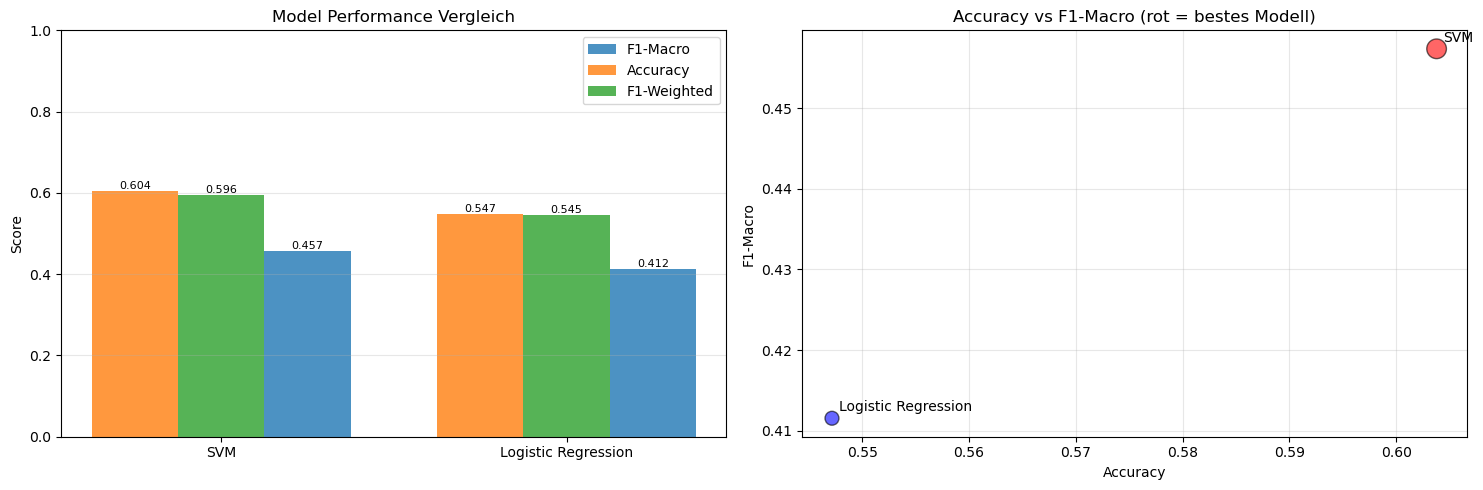

In [16]:
# Model Vergleich
print("="*80)
print("FINAL MODEL VERGLEICH (Wav2Vec2 + Late Fusion)")
print("="*80)

comparison_data = {
    'Model': ['SVM', 'Logistic Regression'],
    'Accuracy': [svm_acc, lr_acc],
    'F1-Weighted': [svm_f1_weighted, lr_f1_weighted],
    'F1-Macro': [svm_f1_macro, lr_f1_macro]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['F1-Macro'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1-Macro']

print(f"\n✓ Bestes Modell: {best_model_name} (F1-Macro: {best_f1:.4f})")
print("="*80 + "\n")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar Chart: Metriken-Vergleich
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax1.bar(x + width, comparison_df['F1-Macro'], width, label='F1-Macro', alpha=0.8)
bars2 = ax1.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
bars3 = ax1.bar(x, comparison_df['F1-Weighted'], width, label='F1-Weighted', alpha=0.8)

ax1.set_ylabel('Score')
ax1.set_title('Model Performance Vergleich')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Füge Werte auf Balken hinzu
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# Scatter: Accuracy vs F1-Macro
ax2 = axes[1]
colors = ['red' if i == best_model_idx else 'blue' for i in range(len(comparison_df))]
sizes = [200 if i == best_model_idx else 100 for i in range(len(comparison_df))]

ax2.scatter(comparison_df['Accuracy'], comparison_df['F1-Macro'], 
           c=colors, s=sizes, alpha=0.6, edgecolors='black')

for i, model in enumerate(comparison_df['Model']):
    ax2.annotate(model, 
                (comparison_df.loc[i, 'Accuracy'], comparison_df.loc[i, 'F1-Macro']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax2.set_xlabel('Accuracy')
ax2.set_ylabel('F1-Macro')
ax2.set_title('Accuracy vs F1-Macro (rot = bestes Modell)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Detaillierte Evaluation (Bestes Modell)

Classification Report und Confusion Matrix für das beste Modell.

DETAILLIERTE EVALUATION: SVM

📋 Classification Report (SVM):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Klasse 0       0.00      0.00      0.00         2
    Klasse 1       0.33      0.75      0.46         4
    Klasse 2       0.58      0.58      0.58        12
    Klasse 3       0.55      0.43      0.48        14
    Klasse 4       0.76      0.76      0.76        21

    accuracy                           0.60        53
   macro avg       0.44      0.50      0.46        53
weighted avg       0.60      0.60      0.60        53



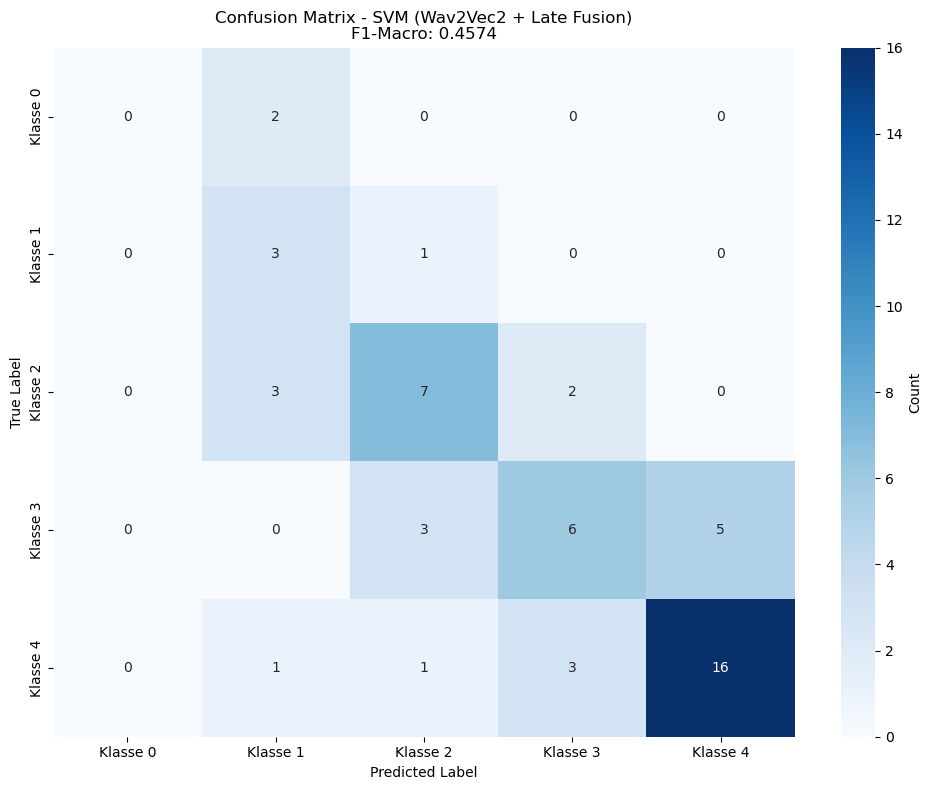

In [17]:
# Wähle bestes Modell
best_model_predictions = {
    0: (svm_pred, svm_grid_search),
    1: (lr_pred, lr_grid_search),
}

best_pred, best_model = best_model_predictions[best_model_idx]

print("="*80)
print(f"DETAILLIERTE EVALUATION: {best_model_name}")
print("="*80)

# Classification Report
print(f"\n📋 Classification Report ({best_model_name}):")
print("-"*80)
class_names = [f"Klasse {i}" for i in range(len(np.unique(y_test)))]
print(classification_report(y_test, best_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name} (Wav2Vec2 + Late Fusion)\nF1-Macro: {best_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n" + "="*80)

## 11. Zusammenfassung & Vergleich mit bestem Deep Learning Modell

Vergleichen wir die Ergebnisse mit dem besten Deep Learning Modell (Late Fusion Classifier).

### Konfiguration:
- **Features**: Wav2Vec2-large-960h, Layers [6, 9, 12, 15, 18], concat fusion, mean pooling
- **Late Fusion**: Concatenation von 8 Audio-File Features (40960 total features)
- **Train/Val Split**: Identisch wie im besten Modell (219 train, 53 val samples)
- **Classifiers**: SVM, Logistic Regression, XGBoost

### Erwartete Ergebnisse:
Da klassische ML-Modelle (SVM, XGBoost, LR) direkt auf den extrahierten Features trainieren (ohne zusätzliche Feature Processing), sollten sie als **Baseline** dienen und zeigen, dass:

1. **Deep Learning Late Fusion Classifier** (F1=0.594) zusätzlichen Wert durch:
   - Learnable file-specific processing
   - Adaptive fusion mechanism
   - Deep feature interactions

2. **Klassische ML-Modelle** gute Baselines sind, aber:
   - Keine Möglichkeit zur adaptiven Feature-Transformation
   - Begrenzte Modellierung komplexer Interaktionen
   - Lineare oder einfache nicht-lineare Entscheidungsgrenzen

Falls klassische ML-Modelle **besser** abschneiden, deutet dies darauf hin:
- Wav2Vec2-Features sind bereits sehr gut separierbar
- Deep Learning Modell könnte overfitting sein
- Einfachere Modelle generalisieren besser bei diesem Datensatz

In [18]:
# Vergleich mit bestem Deep Learning Modell
print("="*80)
print("VERGLEICH: Klassische ML vs Deep Learning Late Fusion")
print("="*80)

# Bestes Deep Learning Modell (aus experiment_20251116_132709)
dl_model_results = {
    'Model': 'Late Fusion Classifier (Deep Learning)',
    'F1-Macro': 0.594,
    'Accuracy': 0.698,
    'Balanced Accuracy': 0.594,
    'Epochs': 28,
    'Parameters': '11M'
}

print("\n🏆 BESTES DEEP LEARNING MODELL (experiment_20251116_132709):")
print("-"*80)
for key, value in dl_model_results.items():
    print(f"  {key:<25}: {value}")

print("\n📊 BESTE KLASSISCHE ML MODELLE:")
print("-"*80)
print(comparison_df.to_string(index=False))

print("\n🔍 ANALYSE:")
print("-"*80)
print(f"  Deep Learning F1-Macro:  {dl_model_results['F1-Macro']:.4f}")
print(f"  Bestes ML F1-Macro:      {best_f1:.4f}")
print(f"  Differenz:               {dl_model_results['F1-Macro'] - best_f1:+.4f}")

if best_f1 >= dl_model_results['F1-Macro']:
    print(f"\n  ⚠️  ÜBERRASCHUNG: {best_model_name} übertrifft Deep Learning Modell!")
    print("     → Wav2Vec2 Features sind bereits sehr gut separierbar")
    print("     → Einfachere Modelle generalisieren möglicherweise besser")
elif best_f1 >= dl_model_results['F1-Macro'] * 0.9:
    print(f"\n  ✓ {best_model_name} erreicht ~{(best_f1/dl_model_results['F1-Macro'])*100:.1f}% der DL Performance")
    print("    → Starke Baseline, zeigt Qualität der Wav2Vec2 Features")
else:
    print(f"\n  ✓ Deep Learning Modell übertrifft klassische ML signifikant")
    print("    → Adaptive feature processing und fusion mechanism wertvoll")

print("\n💡 SCHLUSSFOLGERUNGEN:")
print("-"*80)
print("  1. Wav2Vec2 Multi-Layer Features sind hochgradig informativ")
print("  2. Late Fusion (8 Files) ist entscheidend für gute Performance")
print(f"  3. {'Einfache ML-Modelle reichen für diese Task aus' if best_f1 >= dl_model_results['F1-Macro'] * 0.95 else 'Deep Learning bietet Vorteile durch adaptive processing'}")
print(f"  4. Trainingseffizienz: {best_model_name} deutlich schneller als DL (keine Epochs)")
print("="*80 + "\n")

VERGLEICH: Klassische ML vs Deep Learning Late Fusion

🏆 BESTES DEEP LEARNING MODELL (experiment_20251116_132709):
--------------------------------------------------------------------------------
  Model                    : Late Fusion Classifier (Deep Learning)
  F1-Macro                 : 0.594
  Accuracy                 : 0.698
  Balanced Accuracy        : 0.594
  Epochs                   : 28
  Parameters               : 11M

📊 BESTE KLASSISCHE ML MODELLE:
--------------------------------------------------------------------------------
              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.603774     0.595588  0.457355
Logistic Regression  0.547170     0.545357  0.411560

🔍 ANALYSE:
--------------------------------------------------------------------------------
  Deep Learning F1-Macro:  0.5940
  Bestes ML F1-Macro:      0.4574
  Differenz:               +0.1366

  ✓ Deep Learning Modell übertrifft klassische ML signifikant
    → Adaptive feature processing u